In [1]:
# # Run this and then restart the kernel at the start of each session to install
# # 'teotil3' in development mode
# !pip install -e /home/jovyan/projects/teotil3/

In [2]:
import lillestrom_utils as utils
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import teotil3 as teo

plt.style.use("ggplot")

# TEOTIL3 for Lillestrøm kommune
# Notebook 09: Avlastningsbehov and scenarios

## 1. Read and combine datasets

In [3]:
# TEOTIL options
st_yr = 2013
end_yr = 2024
nve_data_yr = 2025
agri_loss_model = "annual"
par_dict = {"TOTN": "Total nitrogen", "TOTP": "Total phosphorous"}
comp_st_yr = 2015
comp_end_yr = 2024
gts_bias_fac = 1.2

In [4]:
# Read site data
xl_path = r"../data/lillestrom_monitoring_sites.xlsx"
stn_df = pd.read_excel(xl_path, sheet_name="chem_stns")
stn_df = stn_df[stn_df["comment"].str.startswith("Downstream")]

# Read Vann-Nett data
xl_path = r"../data/vann-nett_data.xlsx"
vn_df = pd.read_excel(xl_path)

# Thresholds for clay catchments
xl_path = r"../data/leirvassdrag_totp_god-mod_boundaries.xlsx"
clay_df = pd.read_excel(xl_path).set_index("wb_id")

# TEOTIL3 results
xl_path = r"../data/teotil3_modelled_loads_waterbodies.xlsx"
teo_df = pd.read_excel(xl_path, sheet_name="default")

# Read NVE data and apply bias correction
xl_path = r"../data/nve_data.xlsx"
q_df = pd.read_excel(xl_path, sheet_name="gts-api")
q_df = (q_df.set_index('date') * gts_bias_fac).reset_index()
q_df["year"] = q_df["date"].dt.year

# Read annual loads
xl_path = r"../data/annual_loads_waterbodies.xlsx"
obs_lds_df = pd.read_excel(xl_path, sheet_name="annual_loads").drop(
    columns=["SS_tonn", "TOC_tonn"]
)

stn_df.head()

,catchment,station_id,station_name,regine,wb_id,wb_name,lon,lat,comment
0,Sagelva,002-46599,Sagelva ved Skjetten bro (F3),002.CBA0,002-3899-R,Fjellhamarelva - Sagelva,11.01695,59.95850,Downstream
2,Nitelva,002-30586,Rud Nitelva (N8),002.CB0,002-3891-R,Nedre Nitelva,11.05700,59.94553,Downstream
4,Leira,002-29659,Leira ved Borgen bru (L5),002.CAA0,002-3384-R,Leira nedstrøms Krokfoss,11.10032,59.95036,Downstream
6,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,002.D2Z,002-3659-R,Rømua,11.22099,60.02163,Downstream
7,Jeksla,002-30593,"Jeksla ved Haugli, J14",002.CAA0,002-599-R,Jeksla,11.10637,60.00199,Downstream. Small part of regine


## 2. Estimate avlastningsbehov

In [5]:
df_list = []
for idx, row in stn_df.iterrows():
    cat = row["catchment"]
    reg_id = row["regine"]
    wb_id = row["wb_id"]
    stn_id = row["station_id"]

    for par, vn_par in par_dict.items():
        vn_par_df = vn_df.query("(waterbody_id == @wb_id) and (parameter == @vn_par)")
        assert len(vn_par_df) == 1
        vn_status = vn_par_df.iloc[0]["status"]
        vn_conc = vn_par_df.iloc[0]["value"]
        vn_st_yr = vn_par_df.iloc[0]["year_from"]
        vn_end_yr = vn_par_df.iloc[0]["year_to"]
        vn_thresh = vn_par_df.iloc[0]["status_limits"]
        if isinstance(vn_thresh, str):
            ges_conc = float(vn_thresh.split(";")[1])
        else:
            assert par == "TOTP"
            ges_conc = clay_df.loc[wb_id, "totp_mod-god_ugpl"]

        # Get modelled loads
        mod_df = teo_df.query("(wb_id == @wb_id) and (Parameter == @par)").rename(
            columns={"År": "year"}
        )
        id_cols = ["catchment", "wb_id", "wb_name", "regine", "Parameter", "year"]
        val_cols = [col for col in mod_df.columns if col not in id_cols]
        mod_df["mod_tonn"] = mod_df[val_cols].sum(axis=1)
        mod_df = mod_df[["year", "mod_tonn"]].set_index("year")

        # Get observed loads
        wb_obs_lds = (
            obs_lds_df.query("waterbody_id == @wb_id")[["year", f"{par}_tonn"]]
            .set_index("year")
            .rename(columns={f"{par}_tonn": "obs_tonn"})
        )

        # Calculate annual flow volume
        ges_lds_df = q_df[["year", stn_id]].copy()
        ges_lds_df["vol_l"] = ges_lds_df[stn_id] * 1000 * 60 * 60 * 24

        # Print median Q and annual vol of period of interest
        q_stat_df = ges_lds_df[["year", stn_id, "vol_l"]].groupby("year").agg(
            {stn_id: "mean", "vol_l": "sum"}
        ).median()
        ann_q = q_stat_df[stn_id] # m3/s
        ann_vol = q_stat_df['vol_l'] / 1e9 # Mm3/year
        print(f"{cat} ({par}): {ann_q:.4f} m3/s ({ann_vol:.2f} Mm3/year)")

        # Get max load for GES    
        ges_lds_df = ges_lds_df[["year", "vol_l"]].groupby("year").sum()
        ges_lds_df["max_tonn"] = ges_conc * ges_lds_df["vol_l"] / 1e12
        ges_lds_df = ges_lds_df[["max_tonn"]]

        res_df = pd.concat(
            [ges_lds_df, wb_obs_lds, mod_df], axis="columns"
        ).reset_index()
        res_df["catchment"] = cat
        res_df["wb_id"] = wb_id
        res_df["par"] = par
        id_cols = ["catchment", "wb_id", "par", "year"]
        val_cols = [col for col in res_df.columns if col not in id_cols]
        res_df = res_df[id_cols + val_cols].sort_values(id_cols)
        df_list.append(res_df)
res_df = pd.concat(df_list, axis="rows")

res_df["avlast_obs_tonn"] = (res_df["obs_tonn"] - res_df["max_tonn"]).clip(lower=0)
res_df["avlast_mod_tonn"] = (res_df["mod_tonn"] - res_df["max_tonn"]).clip(lower=0)
res_df["avlast_obs_pct"] = 100 * res_df["avlast_obs_tonn"] / res_df["obs_tonn"]
res_df["avlast_mod_pct"] = 100 * res_df["avlast_mod_tonn"] / res_df["mod_tonn"]

Sagelva (TOTN): 1.4861 m3/s (46.03 Mm3/year)
Sagelva (TOTP): 1.4861 m3/s (46.03 Mm3/year)
Nitelva (TOTN): 9.0013 m3/s (281.51 Mm3/year)
Nitelva (TOTP): 9.0013 m3/s (281.51 Mm3/year)
Leira (TOTN): 11.5049 m3/s (362.82 Mm3/year)
Leira (TOTP): 11.5049 m3/s (362.82 Mm3/year)
Rømua (TOTN): 2.5176 m3/s (79.39 Mm3/year)
Rømua (TOTP): 2.5176 m3/s (79.39 Mm3/year)
Jeksla (TOTN): 0.1859 m3/s (5.87 Mm3/year)
Jeksla (TOTP): 0.1859 m3/s (5.87 Mm3/year)
Åa (TOTN): 1.5647 m3/s (49.10 Mm3/year)
Åa (TOTP): 1.5647 m3/s (49.10 Mm3/year)
Gansåa (TOTN): 0.3363 m3/s (10.56 Mm3/year)
Gansåa (TOTP): 0.3363 m3/s (10.56 Mm3/year)


In [6]:
comp_st_yr = 2015
comp_end_yr = 2024

avlast_df = res_df.query("@comp_st_yr <= year <= @comp_end_yr").copy()
avlast_dict = {}
for (cat, wb_id), wb_df in avlast_df.groupby(["catchment", "wb_id"]):
    wb_df = (
        wb_df[["par", "avlast_obs_pct", "avlast_mod_pct"]]
        .rename(columns={"avlast_obs_pct": "Observert", "avlast_mod_pct": "Modellert"})
        .melt(id_vars="par", var_name="Datatype", value_name="Avlastningsbehov (%)")
        .dropna()
    )

    g = sn.displot(
        data=wb_df,
        x="Avlastningsbehov (%)",
        col="par",
        hue="Datatype",
        kind="kde",
        clip=(0, 100),
        height=3,
        aspect=1,
    )

    # Add median lines
    for ax, par in zip(g.axes.flat, g.col_names):
        par_data = wb_df[wb_df["par"] == par]

        for var, color in zip(
            par_data["Datatype"].unique(),
            sn.color_palette(n_colors=par_data["Datatype"].nunique()),
        ):
            median = par_data.loc[
                par_data["Datatype"] == var, "Avlastningsbehov (%)"
            ].median()
            mean = par_data.loc[
                par_data["Datatype"] == var, "Avlastningsbehov (%)"
            ].mean()
            print(cat, par, var, median, mean)
            avlast_dict[(cat, par, var)] = median
            ax.axvline(
                median,
                color=color,
                linestyle="--",
                linewidth=1.5,
                alpha=0.8,
            )

    png_path = f"../plots/modelled/avlast_{cat}_waterbody_{wb_id}.png"
    g.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.close()

Gansåa TOTN Observert 23.562763614148594 20.302546368574042
Gansåa TOTN Modellert 35.63160716498167 37.002416864966165
Gansåa TOTP Observert 16.183270170083823 18.29576464628884
Gansåa TOTP Modellert 57.602161863078244 56.15245753505273
Jeksla TOTN Observert 64.09556459176989 66.82464864639151
Jeksla TOTN Modellert 81.43985284476494 80.55251335324206
Jeksla TOTP Observert 20.010416259012388 25.035696053164106
Jeksla TOTP Modellert 73.62610090196118 73.79953071558978
Leira TOTN Observert 41.82453899848932 41.544708188077266
Leira TOTN Modellert 55.39983870227266 55.08678169876657
Leira TOTP Observert 53.73051209285813 53.462705194969466
Leira TOTP Modellert 54.83252309128029 51.58074556328292
Nitelva TOTN Observert 48.026666578794774 43.42165910006989
Nitelva TOTN Modellert 45.33859407570638 44.28928336683667
Nitelva TOTP Observert 2.558521259467631 9.036237706090938
Nitelva TOTP Modellert 41.658909403006 32.51175444247235
Rømua TOTN Observert 67.07202876067853 67.92925288735118
Rømua T

In [7]:
res_df.query("(catchment == 'Nitelva') and (par == 'TOTN') and (year >= 2013)")

,catchment,wb_id,par,year,max_tonn,obs_tonn,mod_tonn,avlast_obs_tonn,avlast_mod_tonn,avlast_obs_pct,avlast_mod_pct
33,Nitelva,002-3891-R,TOTN,2013,221.320831,378.326645,488.543704,157.005814,267.222872,41.500068,54.697844
34,Nitelva,002-3891-R,TOTN,2014,324.757042,NaN,540.524466,NaN,215.767423,NaN,39.918160
35,Nitelva,002-3891-R,TOTN,2015,289.197320,509.211767,497.595031,220.014447,208.397711,43.206866,41.880987
36,Nitelva,002-3891-R,TOTN,2016,202.047247,450.033867,490.285611,247.986620,288.238363,55.103991,58.789888
37,Nitelva,002-3891-R,TOTN,2017,218.668006,413.965941,490.502947,195.297936,271.834941,47.177296,55.419635
38,Nitelva,002-3891-R,TOTN,2018,235.741678,537.323931,586.809203,301.582253,351.067525,56.126712,59.826520
39,Nitelva,002-3891-R,TOTN,2019,336.591362,755.738784,657.356230,419.147422,320.764868,55.461944,48.796201
40,Nitelva,002-3891-R,TOTN,2020,421.133156,823.749053,632.731158,402.615897,211.598002,48.876038,33.442008
41,Nitelva,002-3891-R,TOTN,2021,294.332384,NaN,500.625942,NaN,206.293558,NaN,41.207125
42,Nitelva,002-3891-R,TOTN,2022,203.633192,NaN,491.190835,NaN,287.557643,NaN,58.542958


## 3. Scenario reductions

In [8]:
# Which TEOTIL3 results to use for each Catchment
stat_dict = {
    "Sagelva": "accum",
    "Nitelva": "accum",
    "Leira": "accum",
    "Rømua": "accum",
    "Jeksla": "local",
    "Gansåa": "local",
    "Åa": "local",
}

scen_csv = r"/home/jovyan/shared/common/oslofjord_modelling/phase3_scenarios/teotil3_oslomod_results_2017-2019.csv"
scens = ["Baseline", "Scenario_A", "Scenario_B"]

pars = ["TOTN", "TOTP", "TOC", "SS"]

In [9]:
osl_df = pd.read_csv(scen_csv)
osl_df.head()

,scenario,year,regine,regine_down,accum_agriculture-background_din_kg,accum_agriculture-background_ss_kg,accum_agriculture-background_tdp_kg,accum_agriculture-background_toc_kg,accum_agriculture-background_ton_kg,accum_agriculture-background_totn_kg,...,local_urban_totp_kg,local_urban_tpp_kg,local_wood_din_kg,local_wood_ss_kg,local_wood_tdp_kg,local_wood_toc_kg,local_wood_ton_kg,local_wood_totn_kg,local_wood_totp_kg,local_wood_tpp_kg
0,Baseline,2017,001.10,001.,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,28.1,704.8,0.5,7753.1,145.2,173.3,4.3,3.8
1,Baseline,2017,001.1A2B,001.1A2A,101.705063,66.420112,0.444083,4936.322742,56.349583,158.054645,...,10.8,4.3,1026.0,26580.2,18.6,299026.9,5556.6,6582.6,163.5,144.9
2,Baseline,2017,001.1A4D,001.1A4C,13.761862,12.543802,0.024426,362.237626,5.818261,19.580123,...,0.0,0.0,184.9,4808.5,3.4,54576.8,1010.5,1195.4,29.8,26.4
3,Baseline,2017,001.1M,001.1L,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,368.5,9749.3,6.8,111142.1,2056.1,2424.6,60.9,54.1
4,Baseline,2017,001.21,001.,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,3.9,97.6,0.1,1078.3,20.2,24.1,0.6,0.5


In [10]:
df_list = []
for index, row in stn_df.iterrows():
    stn_id = row["station_id"]
    wb_id = row["wb_id"]
    reg_id = row["regine"]
    name = row["catchment"]
    stat = stat_dict[name]

    for scen in scens:
        reg_sc_df = osl_df.query("(scenario == @scen) and (regine == @reg_id)").copy()
        cols = [i for i in reg_sc_df.columns if i.split("_")[0] == stat]
        reg_sc_df = reg_sc_df[["regine", "year"] + cols]
        reg_sc_df = reg_sc_df.rename(columns={"year": "År"})
        for col in reg_sc_df.columns:
            if col.endswith("_kg"):
                new_col = col.replace("_kg", "_tonnes")
                reg_sc_df[new_col] = reg_sc_df[col] / 1000
                del reg_sc_df[col]

        # Aggregate to desired level
        id_cols = ["regine", "Parameter", "År"]
        for par in pars:
            agg_dict = {
                "Jordbruk": [f"{stat}_agriculture_{par.lower()}_tonnes"],
                "Avløp": [
                    f"{stat}_large-wastewater_{par.lower()}_tonnes",
                    f"{stat}_spredt_{par.lower()}_tonnes",
                ],
                "Industri": [f"{stat}_industry_{par.lower()}_tonnes"],
                "Bebygd": [f"{stat}_urban_{par.lower()}_tonnes"],
                "Bakgrunn": [
                    f"{stat}_agriculture-background_{par.lower()}_tonnes",
                    f"{stat}_upland_{par.lower()}_tonnes",
                    f"{stat}_wood_{par.lower()}_tonnes",
                ],
            }
            par_df = utils.aggregate_parameters(
                reg_sc_df,
                par.lower(),
                agg_dict=agg_dict,
                stat=stat,
            )
            par_df["Parameter"] = par
            val_cols = [col for col in par_df.columns if col not in id_cols]
            par_df = par_df[id_cols + val_cols].sort_values(id_cols)
            par_df["Totalt"] = par_df[val_cols].sum(axis=1)
            par_df["scenario"] = scen
            par_df["catchment"] = name

            df_list.append(par_df)

# Merge
sc_df = pd.concat(df_list, axis="rows")

# Reshape
sc_df = (
    sc_df.drop(columns="År")
    .groupby(["catchment", "regine", "Parameter", "scenario"])
    .sum()
    .unstack("scenario")
)

# Percent changes
for src in sc_df.columns.get_level_values(0).unique():
    for scen in ("Scenario_A", "Scenario_B"):
        sc_df[(src, f"{scen}_pct")] = (
            100
            * (sc_df[(src, scen)] - sc_df[(src, "Baseline")])
            / sc_df[("Totalt", "Baseline")]
        )

pct_columns = [col for col in sc_df.columns if col[1].endswith("_pct")]
pct_df = sc_df[pct_columns]
pct_df = pct_df[["Jordbruk", "Avløp", "Totalt"]]
pct_df.columns = pct_df.columns.map("-".join)
pct_df = pct_df.reset_index()
pct_df = pct_df.melt(
    id_vars=["catchment", "regine", "Parameter"], value_name="Reduksjon (%)"
)
pct_df[["source", "scenario"]] = pct_df["variable"].str.split("-", expand=True)
del pct_df["variable"]
pct_df["scenario"] = pct_df["scenario"].str[:-4]
pct_df = pct_df.query("source != 'Totalt'")

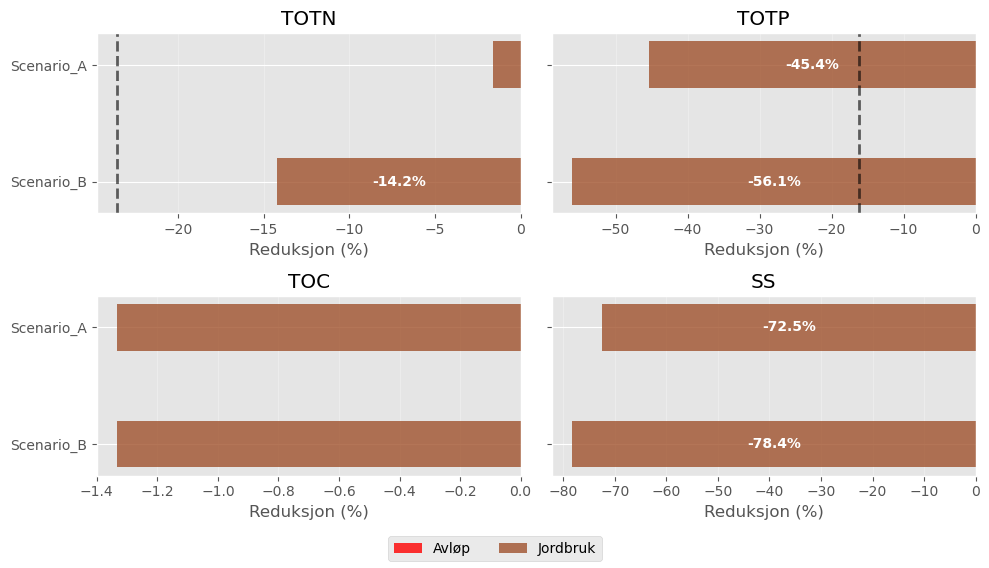

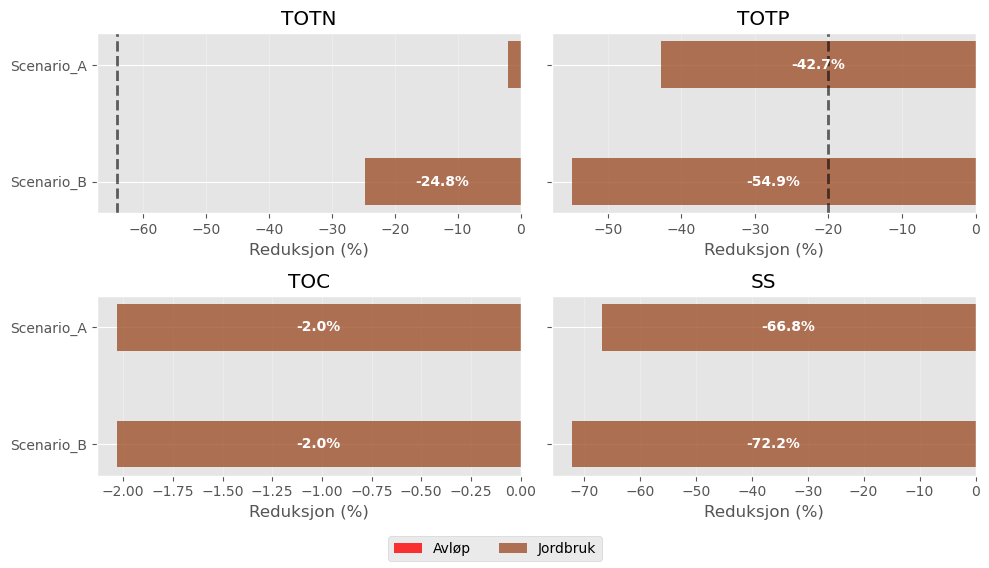

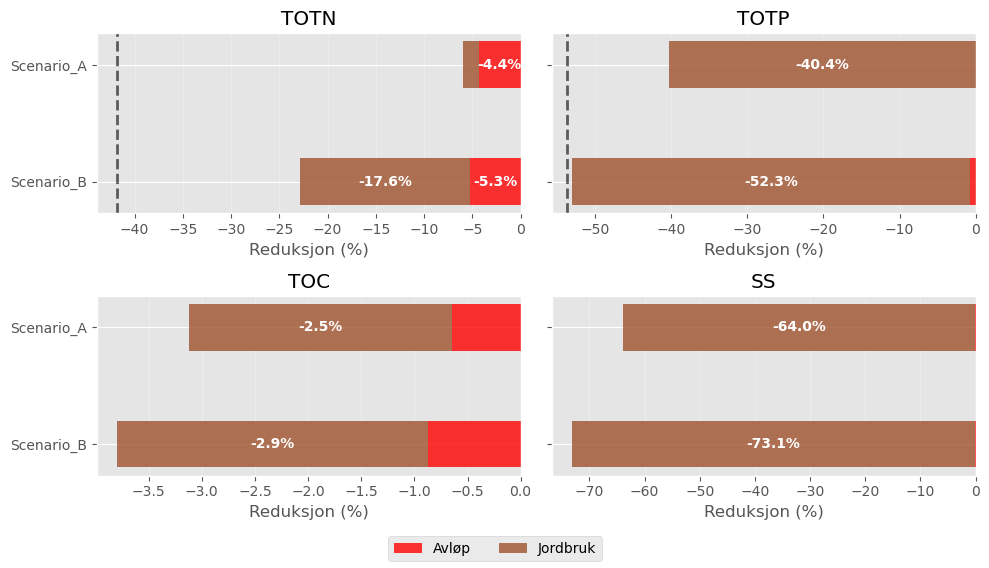

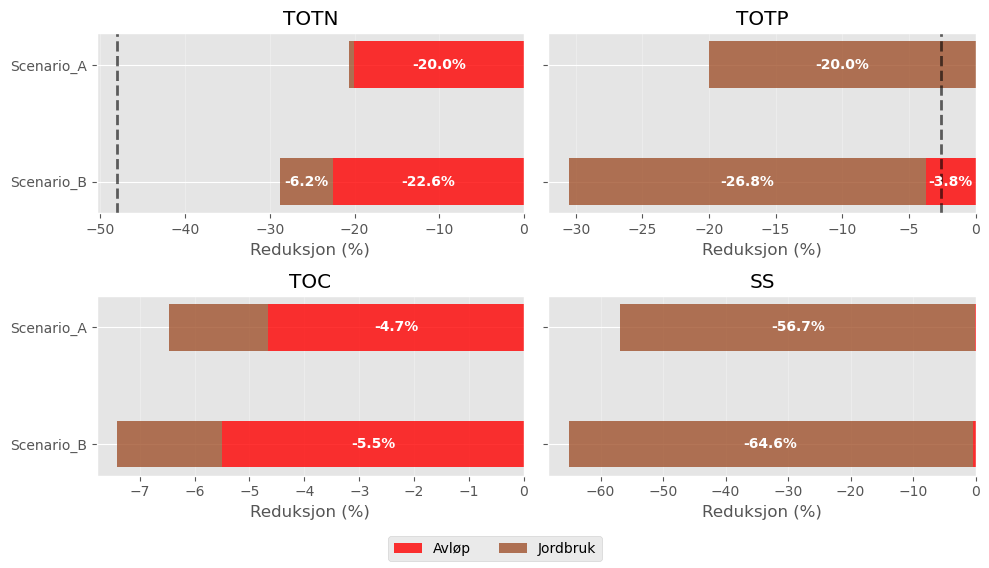

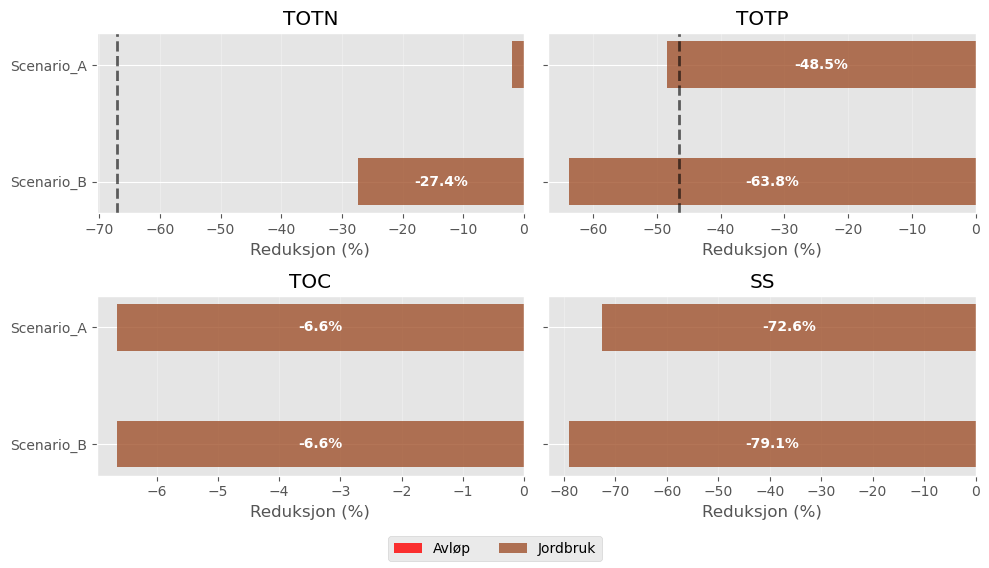

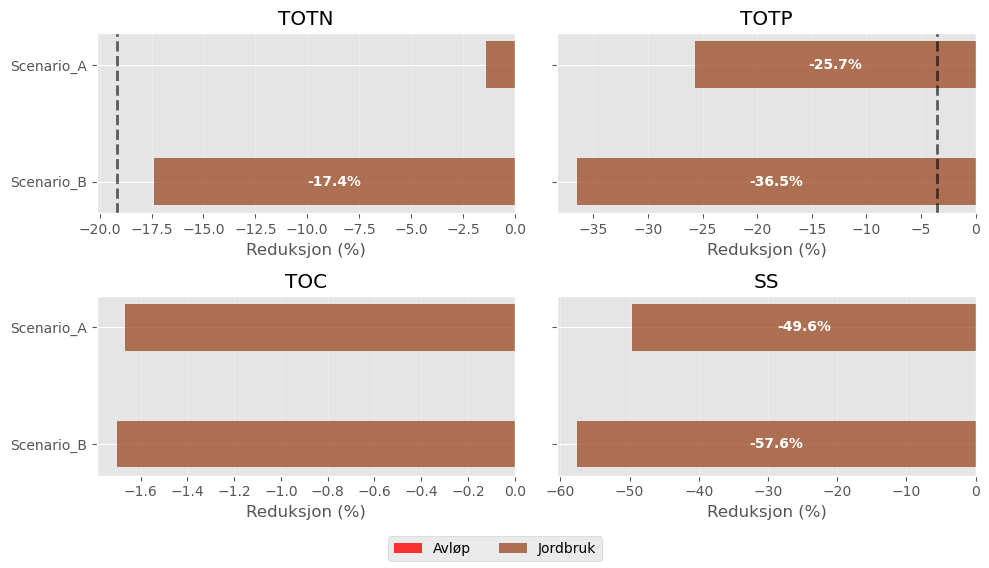

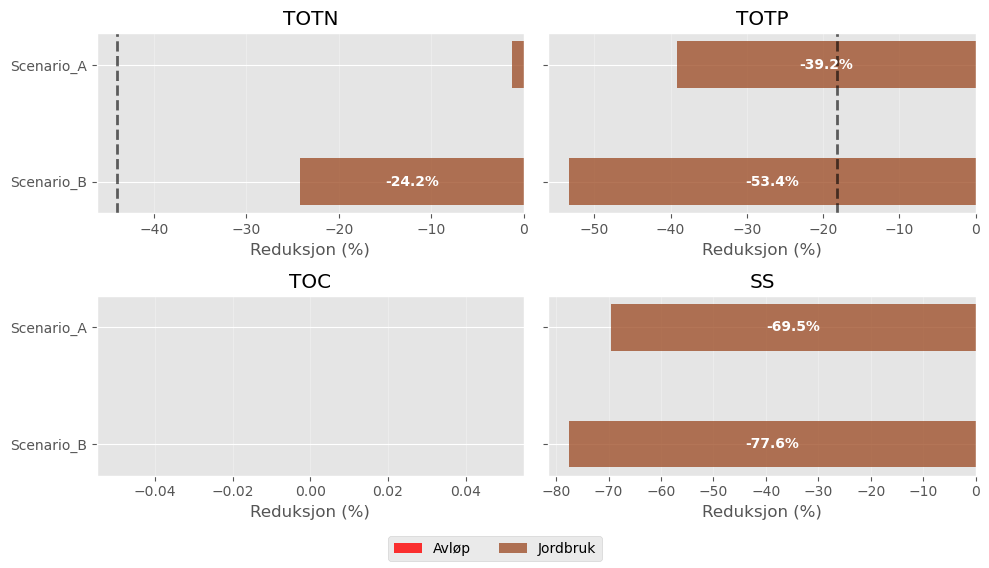

In [11]:
colour_dict = {
    "Jordbruk": "sienna",
    "Avløp": "red",
    "Industri": "darkgrey",
    "Bebygd": "gold",
    "Bakgrunn": "limegreen",
}

scenario_order = ["Scenario_A", "Scenario_B"]

# Loop through catchments
for catchment in pct_df["catchment"].unique():

    df_c = pct_df[pct_df["catchment"] == catchment]

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=False, sharey=True)
    axes = axes.flatten()

    # Plot one parameter per subplot
    for ax, par in zip(axes, pars):

        df_p = df_c[df_c["Parameter"] == par]

        pivot = df_p.pivot_table(
            index="scenario",
            columns="source",
            values="Reduksjon (%)",
            aggfunc="sum",
            fill_value=0,
        )

        # Ensure ScA is on top and ScB below
        pivot = pivot.reindex(scenario_order)
        pivot = pivot.iloc[::-1]  # barh plots lowest index at bottom

        left = pd.Series(0, index=pivot.index)

        for source in pivot.columns:

            bars = ax.barh(
                pivot.index,
                pivot[source],
                left=left,
                height=0.4,  # thinner bars
                label=source,
                color=colour_dict.get(source, "lightgrey"),
                alpha=0.8,
            )

            for bar, value in zip(bars, pivot[source]):
                if abs(value) > 2:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f"{value:.1f}%",
                        ha="center",
                        va="center",
                        fontsize=10,
                        color="white",
                        fontweight="bold",
                    )

            left += pivot[source]

        median = avlast_dict.get((catchment, par, "Observert"))
        if median is not None:
            median = -median
            ax.axvline(
                median,
                color="black",
                linestyle="--",
                linewidth=2,
                alpha=0.6,
            )

        ax.set_title(par)
        ax.set_xlabel("Reduksjon (%)")
        ax.grid(axis="x", alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 5))
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])

    # Save
    png_path = f"../plots/modelled/oslomod_scens_{catchment}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")